In [1]:

from pathlib import Path
import json
import copy
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# Project paths
PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

CHECKPOINT_DIR = PROJECT_ROOT / "ml" / "results" / "checkpoints"
METRICS_DIR = PROJECT_ROOT / "ml" / "results" / "metrics"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Training configuration
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_CLASSES = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Training directory exists:", TRAIN_DIR.exists())
print("Testing directory exists:", TEST_DIR.exists())
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Metrics directory:", METRICS_DIR)

Project root: d:\Projects\Medexplain_AI
Device: cpu
Training directory exists: True
Testing directory exists: True
Checkpoint directory: d:\Projects\Medexplain_AI\ml\results\checkpoints
Metrics directory: d:\Projects\Medexplain_AI\ml\results\metrics


In [2]:

# ImageNet normalization used for pretrained DenseNet-201
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)

# Recreate the same stratified 80/20 split used in previous models
from sklearn.model_selection import train_test_split

indices = np.arange(len(full_train_dataset))
labels = np.array(full_train_dataset.targets)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Classes:", full_train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training images: 4343
Validation images: 1086
Testing images: 1584
Training batches: 272
Validation batches: 68


In [3]:

weights = models.DenseNet201_Weights.DEFAULT
model = models.densenet201(weights=weights)

# Replace the final classifier for our 4 classes
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)

# Freeze the pretrained feature extractor
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("DenseNet-201 loaded successfully")
print("Classifier:", model.classifier)
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Device:", DEVICE)

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to C:\Users\Kanak/.cache\torch\hub\checkpoints\densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:26<00:00, 3.01MB/s]


DenseNet-201 loaded successfully
Classifier: Linear(in_features=1920, out_features=4, bias=True)
Total parameters: 18,100,612
Trainable parameters: 7,684
Device: cpu


In [4]:

# Get one batch of training images
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

# Check the model's output shape
model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Forward pass successful!")

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 4])
Labels shape: torch.Size([16])
Forward pass successful!


In [5]:

# Training history
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "epoch_time_seconds": []
}

best_val_accuracy = 0.0
best_epoch = 0

CHECKPOINT_PATH = CHECKPOINT_DIR / "densenet201_best.pth"
HISTORY_PATH = METRICS_DIR / "densenet201_training_history.json"

for epoch in range(EPOCHS):
    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    # Keep the frozen feature extractor in eval mode
    # so its BatchNorm statistics remain fixed.
    model.features.eval()
    model.classifier.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    epoch_time = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["epoch_time_seconds"].append(epoch_time)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    # Save best model based on validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            {
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "class_to_idx": full_train_dataset.class_to_idx,
                "best_val_accuracy": best_val_accuracy,
                "best_epoch": best_epoch,
                "num_classes": NUM_CLASSES,
                "architecture": "DenseNet-201",
                "learning_rate": LEARNING_RATE,
                "batch_size": BATCH_SIZE
            },
            CHECKPOINT_PATH
        )

        print(f"  Best checkpoint saved: {CHECKPOINT_PATH}")

    # Save history after each epoch, in case training is interrupted
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=4)

print("\nTraining completed!")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best epoch: {best_epoch}")
print("Checkpoint:", CHECKPOINT_PATH)
print("History:", HISTORY_PATH)

Epoch [1/10] Train Loss: 0.9894 | Train Acc: 0.6733 | Val Loss: 0.7516 | Val Acc: 0.7836 | Time: 28.43 min
  Best checkpoint saved: d:\Projects\Medexplain_AI\ml\results\checkpoints\densenet201_best.pth
Epoch [2/10] Train Loss: 0.6254 | Train Acc: 0.8374 | Val Loss: 0.5642 | Val Acc: 0.8416 | Time: 209.25 min
  Best checkpoint saved: d:\Projects\Medexplain_AI\ml\results\checkpoints\densenet201_best.pth
Epoch [3/10] Train Loss: 0.4982 | Train Acc: 0.8595 | Val Loss: 0.4776 | Val Acc: 0.8656 | Time: 22.31 min
  Best checkpoint saved: d:\Projects\Medexplain_AI\ml\results\checkpoints\densenet201_best.pth
Epoch [4/10] Train Loss: 0.4307 | Train Acc: 0.8701 | Val Loss: 0.4264 | Val Acc: 0.8757 | Time: 18.20 min
  Best checkpoint saved: d:\Projects\Medexplain_AI\ml\results\checkpoints\densenet201_best.pth
Epoch [5/10] Train Loss: 0.3899 | Train Acc: 0.8810 | Val Loss: 0.3914 | Val Acc: 0.8858 | Time: 19.82 min
  Best checkpoint saved: d:\Projects\Medexplain_AI\ml\results\checkpoints\densenet20

In [6]:

# Step 2: Evaluate best DenseNet-201 checkpoint on the test set

import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import json

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Paths
processed_dir = Path("../data/processed")
test_dir = processed_dir / "Testing"

checkpoint_path = Path("../results/checkpoints/densenet201_best.pth")
metrics_dir = Path("../results/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_CLASSES = 4

# Class names
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Test transforms: same normalization used during training
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load test dataset
test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Test images:", len(test_dataset))
print("Class mapping:", test_dataset.class_to_idx)

# Load checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint model:", checkpoint.get("model_name"))
print("Best validation accuracy:", checkpoint.get("best_val_accuracy"))
print("Best epoch:", checkpoint.get("epoch"))

# Initialize DenseNet-201 architecture
model = models.densenet201(weights=None)

# Replace final classifier to match 4 classes
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)

# Load trained weights
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

# Verify class mapping
if checkpoint["class_to_idx"] != test_dataset.class_to_idx:
    raise ValueError(
        "Checkpoint and test dataset class mappings do not match!"
    )

# Run inference
all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

# Overall metrics
test_accuracy = accuracy_score(all_labels, all_predictions)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )
)

# Per-class classification report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Confusion matrix: rows = actual, columns = predicted
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3]
)

print("\n" + "=" * 60)
print("DENSENET-201 TEST RESULTS")
print("=" * 60)

print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Weighted Precision:  {weighted_precision:.4f}")
print(f"Weighted Recall:     {weighted_recall:.4f}")
print(f"Weighted F1-score:   {weighted_f1:.4f}")
print(f"Macro Precision:     {macro_precision:.4f}")
print(f"Macro Recall:        {macro_recall:.4f}")
print(f"Macro F1-score:      {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    zero_division=0
))

print("\nConfusion Matrix:")
print(cm)

# Save results
results = {
    "model_name": "DenseNet-201",
    "best_epoch": checkpoint.get("epoch"),
    "best_validation_accuracy": float(
        checkpoint.get("best_val_accuracy", 0)
    ),
    "test_images": int(len(test_dataset)),
    "test_accuracy": float(test_accuracy),
    "test_correct": int((all_predictions == all_labels).sum()),
    "test_incorrect": int((all_predictions != all_labels).sum()),
    "weighted_precision": float(weighted_precision),
    "weighted_recall": float(weighted_recall),
    "weighted_f1": float(weighted_f1),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "class_names": class_names,
    "classification_report": report,
    "confusion_matrix": cm.tolist()
}

results_path = metrics_dir / "densenet201_test_results.json"

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("\nResults saved to:", results_path)

Test images: 1584
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Checkpoint model: None
Best validation accuracy: 0.9042357274401474
Best epoch: None

DENSENET-201 TEST RESULTS
Test Accuracy:       0.8428 (84.28%)
Weighted Precision:  0.8426
Weighted Recall:     0.8428
Weighted F1-score:   0.8373
Macro Precision:     0.8429
Macro Recall:        0.8412
Macro F1-score:      0.8366

Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.68      0.77       386
  meningioma       0.75      0.71      0.73       398
     notumor       0.86      0.99      0.92       400
   pituitary       0.87      0.97      0.92       400

    accuracy                           0.84      1584
   macro avg       0.84      0.84      0.84      1584
weighted avg       0.84      0.84      0.84      1584


Confusion Matrix:
[[264  83  29  10]
 [ 31 283  35  49]
 [  1   1 398   0]
 [  1   9   0 390]]

Results saved to: ..\results\met

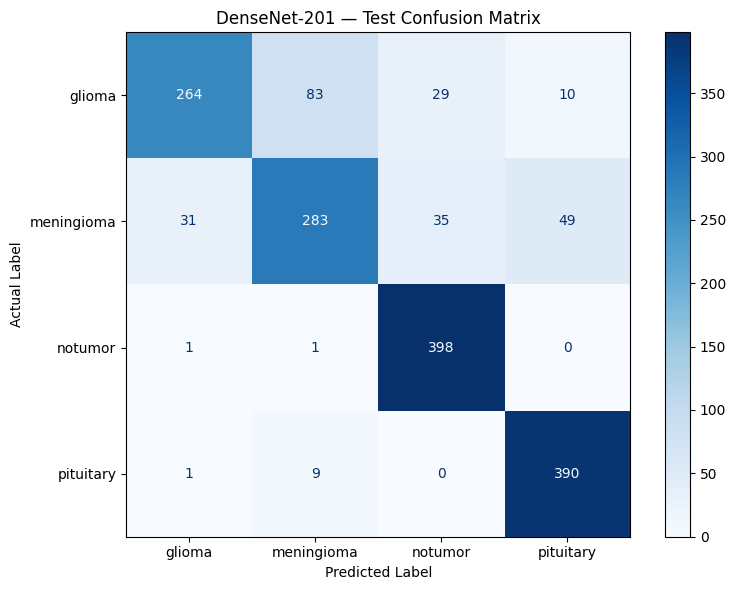

Confusion matrix saved to: ..\results\metrics\densenet201_confusion_matrix.png


In [7]:

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title("DenseNet-201 — Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

plt.tight_layout()

# Save figure
confusion_matrix_path = metrics_dir / "densenet201_confusion_matrix.png"

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)